In [ ]:
y
yimport pandas as pd

url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"

!wget -q $url
!unzip -q ml-100k.zip

replace ml-100k/allbut.pl? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/mku.sh? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace ml-100k/mku.sh? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/README? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u.data? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u.genre? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u.info? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u.item? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u.occupation? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u.user? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u1.base? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u1.test? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u2.base? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u2.test? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u3.base? [y]es, [n]o, [A]ll, [N]one, [r]ename

In [ ]:
ratings = pd.read_csv(
    "ml-100k/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
print("Number of interactions:", len(ratings))
print("Number of users:", ratings["user_id"].nunique())
print("Number of movies:", ratings["movie_id"].nunique())

print("\nRating distribution:")
print(ratings["rating"].value_counts().sort_index())

Number of interactions: 100000
Number of users: 943
Number of movies: 1682

Rating distribution:
rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64


In [ ]:
interactions = ratings[ratings["rating"] >= 4].copy()

interactions["interaction"] = 1

interactions = interactions[
    ["user_id", "movie_id", "interaction", "timestamp"]
]

interactions.head()

,user_id,movie_id,interaction,timestamp
5,298,474,1,884182806
7,253,465,1,891628467
11,286,1014,1,879781125
12,200,222,1,876042340
16,122,387,1,879270459


In [ ]:
print("Positive interactions:", len(interactions))
print("Users:", interactions["user_id"].nunique())
print("Movies:", interactions["movie_id"].nunique())

Positive interactions: 55375
Users: 942
Movies: 1447


In [ ]:
movie_popularity = (
    interactions.groupby("movie_id")
    .size()
    .reset_index(name="interaction_count")
    .sort_values("interaction_count", ascending=False)
)

movie_popularity.head(10)


,movie_id,interaction_count
49,50,501
99,100,406
178,181,379
124,127,351
171,174,348
97,98,344
255,258,344
0,1,321
283,286,298
55,56,294


In [ ]:
print(movie_popularity["interaction_count"].describe())

count    1447.000000
mean       38.268832
std        57.956847
min         1.000000
25%         3.000000
50%        13.000000
75%        47.500000
max       501.000000
Name: interaction_count, dtype: float64


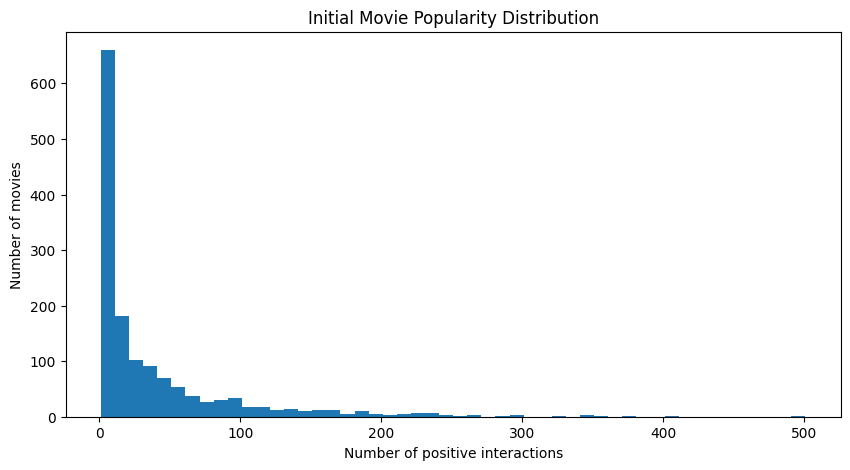

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    movie_popularity["interaction_count"],
    bins=50
)

plt.xlabel("Number of positive interactions")
plt.ylabel("Number of movies")
plt.title("Initial Movie Popularity Distribution")

plt.show()

### Initial Popularity Distribution

We define the popularity of a movie as the number of positive interactions it receives. In our dataset, a positive interaction means that a user gave the movie a rating of 4 or 5.

There are 1,447 movies with at least one positive interaction. The popularity distribution is highly skewed:

- The average movie has about 38 positive interactions.
- The median is only 13 interactions, meaning that half of the movies have 13 or fewer interactions.
- The most popular movie has 501 interactions.
- Some movies have received only 1 positive interaction.

The histogram shows this long-tail distribution. Most movies are concentrated on the left side with relatively few interactions, while only a small number of movies receive hundreds of interactions.

This existing imbalance is important for our experiment because it provides the initial popularity structure. We will later train a recommendation model on this data and simulate user feedback. If popular movies are recommended more often, they may receive more interactions, making them even more popular. We will then study whether this feedback loop increases popularity bias and changes the learned user and item embeddings over successive cycles.

In [ ]:
low_threshold = movie_popularity["interaction_count"].quantile(0.20)
high_threshold = movie_popularity["interaction_count"].quantile(0.80)

print("20th percentile:", low_threshold)
print("80th percentile:", high_threshold)

20th percentile: 3.0
80th percentile: 60.0


### Defining Popularity Groups

We have 1,447 movies, and each movie has a different number of positive interactions.

To divide the movies according to their popularity, we use percentiles.

The 20th percentile is **3 interactions**. This means that roughly the bottom 20% of movies have 3 or fewer positive interactions. These represent the **long-tail** of the dataset.

The 80th percentile is **60 interactions**. This means that roughly 80% of the movies have 60 or fewer positive interactions. Therefore, the movies with more than 60 interactions represent approximately the top 20% and are considered the **popular/head** items.

Based on these thresholds, we will initially divide the movies into:

- **Long-tail:** 1–3 positive interactions
- **Middle:** 4–60 positive interactions
- **Head/Popular:** more than 60 positive interactions

These groups allow us to track how the recommender system treats less popular and highly popular movies during the feedback cycles.

Our main question will be whether repeated recommendation and user-feedback cycles cause the popular items to receive an increasing share of interactions, while long-tail items receive relatively less exposure.

In [ ]:
def classify_popularity(count):
    if count <= 3:
        return "Long-tail"
    elif count <= 60:
        return "Middle"
    else:
        return "Head"

movie_popularity["popularity_group"] = (
    movie_popularity["interaction_count"]
    .apply(classify_popularity)
)

movie_popularity.head(10)

,movie_id,interaction_count,popularity_group
49,50,501,Head
99,100,406,Head
178,181,379,Head
124,127,351,Head
171,174,348,Head
97,98,344,Head
255,258,344,Head
0,1,321,Head
283,286,298,Head
55,56,294,Head


In [ ]:
group_counts = movie_popularity["popularity_group"].value_counts()

print(group_counts)

popularity_group
Middle       788
Long-tail    371
Head         288
Name: count, dtype: int64


In [ ]:
group_percentages = (
    movie_popularity["popularity_group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(group_percentages)

popularity_group
Middle       54.46
Long-tail    25.64
Head         19.90
Name: proportion, dtype: float64


### Train-Test Split

We divide the positive implicit interactions into training and testing sets.

For each user, 80% of their positive interactions are used for training and 20% are held out for testing. The recommendation model will only see the training interactions.

The test interactions are kept hidden during training and are used later to evaluate whether the model can recommend items that the user actually interacted with.

This split is performed separately for each user so that users with positive interactions are represented in both the training and testing data.

In [ ]:
from sklearn.model_selection import train_test_split

train_parts = []
test_parts = []

for user_id, user_data in interactions.groupby("user_id"):
    train, test = train_test_split(
        user_data,
        test_size=0.2,
        random_state=42
    )

    train_parts.append(train)
    test_parts.append(test)

train_data = pd.concat(train_parts).reset_index(drop=True)
test_data = pd.concat(test_parts).reset_index(drop=True)

print("Training interactions:", len(train_data))
print("Testing interactions:", len(test_data))

Training interactions: 43929
Testing interactions: 11446


In [ ]:
print("Training users:", train_data["user_id"].nunique())
print("Testing users:", test_data["user_id"].nunique())

Training users: 942
Testing users: 942


### Baseline Recommendation Model: Matrix Factorization

We use Matrix Factorization (MF) as the baseline recommendation model for this experiment.

The model learns two sets of embeddings from the training interactions:

- **User embeddings:** a vector representation of each user.
- **Item embeddings:** a vector representation of each movie.

We use an embedding dimension of 32, so every user and movie is represented by a 32-dimensional vector.

The model learns these representations from the observed positive interactions. A user's embedding and an item's embedding are used to estimate how likely the user is to interact with that item.

Matrix Factorization is chosen because it provides a simple and interpretable baseline while directly producing the user and item embeddings that we need to study.

After training the baseline model, we will save the item embeddings and recommendation results. These will form the starting point (Cycle 0) of our experiment.

In later cycles, we will simulate user feedback based on the recommendations, add the new interactions to the training data, retrain the model, and compare the new embeddings with those from previous cycles.

The main objective is to investigate whether repeated feedback cycles increase popularity bias and whether this bias is reflected in the learned embedding space.

In [ ]:
# Get unique users and movies from the training data
user_ids = train_data["user_id"].unique()
movie_ids = train_data["movie_id"].unique()

# Map original IDs to continuous indices starting from 0
user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}

# Add the corresponding indices to the training data
train_data["user_idx"] = train_data["user_id"].map(user_to_idx)
train_data["movie_idx"] = train_data["movie_id"].map(movie_to_idx)

print("Number of users:", len(user_to_idx))
print("Number of movies:", len(movie_to_idx))

Number of users: 942
Number of movies: 1413


In [ ]:
# Check how the original IDs and model indices look together
train_data[["user_id", "user_idx", "movie_id", "movie_idx", "interaction"]]

,user_id,user_idx,movie_id,movie_idx,interaction
0,1,0,68,0,1
1,1,0,160,1,1
2,1,0,239,2,1
3,1,0,108,3,1
4,1,0,175,4,1
...,...,...,...,...,...
43924,943,941,426,955,1
43925,943,941,732,502,1
43926,943,941,184,584,1
43927,943,941,193,92,1


In [ ]:
import torch
import torch.nn as nn

In [ ]:
class MatrixFactorization(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=32):
        super().__init__()

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

    def forward(self, user_idx, item_idx):
        user_vector = self.user_embedding(user_idx)
        item_vector = self.item_embedding(item_idx)

        score = (user_vector * item_vector).sum(dim=1)

        return score

In [ ]:
num_users = len(user_to_idx)
num_items = len(movie_to_idx)

embedding_dim = 32

model = MatrixFactorization(
    num_users=num_users,
    num_items=num_items,
    embedding_dim=embedding_dim
)

print(model)

MatrixFactorization(
  (user_embedding): Embedding(942, 32)
  (item_embedding): Embedding(1413, 32)
)


In [ ]:
# Inspect the first few dimensions of the initial user and item embeddings
print("User embedding shape:", model.user_embedding.weight.shape)
print("Item embedding shape:", model.item_embedding.weight.shape)

print("\nFirst user embedding:")
print(model.user_embedding.weight[0])

print("\nFirst item embedding:")
print(model.item_embedding.weight[0])

User embedding shape: torch.Size([942, 32])
Item embedding shape: torch.Size([1413, 32])

First user embedding:
tensor([ 0.8864, -0.0076,  0.6332, -0.7532,  0.7540, -0.9335, -0.4798,  0.7829,
         1.4147, -1.4146, -0.3714,  0.4227,  0.3589,  1.4950,  0.7693,  0.0022,
        -2.0846,  1.1180, -0.5498, -0.2697,  0.9929,  0.5118,  0.9878, -0.4715,
         0.4637,  0.8764,  0.1803,  0.6135, -1.3430, -0.5089, -0.3003,  1.4014],
       grad_fn=<SelectBackward0>)

First item embedding:
tensor([-0.0339, -1.1870,  0.4983, -0.0668, -0.1573,  0.8504, -0.4837, -0.8722,
         1.1937,  1.1837, -0.2451, -0.2627, -0.6102,  1.1624,  0.9776,  0.2422,
        -0.6270,  0.1050, -1.4541,  0.8302,  0.1615, -0.6560, -0.8441,  1.2532,
        -1.7494, -0.5740,  0.5834,  0.5278, -0.3099,  1.1552, -0.2340, -1.1103],
       grad_fn=<SelectBackward0>)


### Understanding User and Item Embeddings

An embedding is a numerical vector used to represent a user or an item in a lower-dimensional space.

In our Matrix Factorization model, every user is represented by a 32-dimensional vector, and every movie is also represented by a 32-dimensional vector.

For example:

User 1 → [0.21, -0.43, 0.87, ..., 0.15]

Movie 10 → [0.52, -0.17, 0.91, ..., -0.08]

These numbers are not manually assigned. They are learned by the model from the user–movie interaction data.

Initially, the embeddings are randomly initialized, so they do not have meaningful information. During training, the model updates them so that users and movies with compatible interaction patterns become more similar in the embedding space.

The model uses the user and item embeddings to calculate an interaction score. A higher score means that the model predicts that the user is more likely to interact with that movie.

For our research, the item embeddings are particularly important. After each feedback cycle, we will save the item embeddings and compare them with the embeddings from previous cycles.

This allows us to investigate whether repeated feedback and increasing popularity bias change the structure of the embedding space, particularly the representations of Head, Middle, and Long-tail items.


### Negative Sampling for Implicit Feedback

Our dataset contains only positive interactions, where an interaction means that a user gave a movie a rating of 4 or 5.

For training the recommendation model, we also need examples of items that the user did not positively interact with. These are called negative samples.

A negative sample does not mean that the user disliked the movie. It only means that we do not have an observed positive interaction for that user and movie in the training data.

For each user, we will therefore create negative samples by selecting movies that are not present among that user's positive training interactions.

For example, if a user interacted with Movies A, B, and C, we can sample Movie D as a negative example:

User → Movie A → 1 (positive)
User → Movie B → 1 (positive)
User → Movie D → 0 (negative)

We will initially use a 1:1 negative-to-positive ratio, meaning that for every positive training interaction, we will generate one negative sample.

This allows the Matrix Factorization model to learn which items are associated with observed user interactions and which sampled items are not.

The negative samples will be generated only from the training data. The held-out test data will remain untouched for evaluation.


In [ ]:
# Store the movies that each user positively interacted with
user_positive_items = (
    train_data.groupby("user_idx")["movie_idx"]
    .apply(set)
    .to_dict()
)

print("Number of users in lookup:", len(user_positive_items))
print("Example:", list(user_positive_items.items())[:1])

Number of users in lookup: 942
Example: [(0, {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129})]


### Generating Negative Samples

We now generate one negative sample for every positive training interaction.

For each user, we randomly select a movie that is not present in that user's positive training interactions. The selected movie is assigned an interaction label of 0.

Using a 1:1 ratio gives us the same number of positive and negative examples:

- 43,929 positive interactions
- 43,929 negative samples
- 87,858 total training examples

A fixed random seed is used so that the same negative samples are generated whenever the notebook is run again. This makes the experiment reproducible.

The test data is not used when generating these samples.

In [ ]:
import random

random.seed(42)

negative_samples = []

for user_idx, positive_items in user_positive_items.items():
    for _ in range(len(positive_items)):
        negative_item = random.randrange(num_items)

        while negative_item in positive_items:
            negative_item = random.randrange(num_items)

        negative_samples.append((user_idx, negative_item, 0))

print("Negative samples:", len(negative_samples))

Negative samples: 43929


### Combining Positive and Negative Training Examples

We now combine the observed positive interactions and the generated negative samples into a single training dataset.

Positive interactions are assigned a label of 1, while negative samples are assigned a label of 0.

The resulting dataset contains 87,858 examples with an equal number of positive and negative samples.

This combined dataset will be used to train the Matrix Factorization model. During training, the model will learn to assign higher scores to positive interactions and lower scores to negative samples.

In [ ]:
# Create positive training examples with label 1
positive_samples = train_data[["user_idx", "movie_idx"]].copy()
positive_samples["label"] = 1

# Convert the negative samples into a DataFrame
negative_samples_df = pd.DataFrame(
    negative_samples,
    columns=["user_idx", "movie_idx", "label"]
)

# Combine positive and negative examples
training_data = pd.concat(
    [positive_samples, negative_samples_df],
    ignore_index=True
)

# Shuffle the combined dataset
training_data = training_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Total training examples:", len(training_data))
print("\nLabel distribution:")
print(training_data["label"].value_counts())

Total training examples: 87858

Label distribution:
label
1    43929
0    43929
Name: count, dtype: int64


### Preparing Data for PyTorch

The training data is currently stored as a Pandas DataFrame. PyTorch models operate on tensors, so we convert the user indices, movie indices, and interaction labels into PyTorch tensors.

The user and movie indices are stored as integer tensors because they are used to look up rows in the embedding matrices. The interaction labels are stored as floating-point values because they will be used as target values during the loss calculation.

These tensors will be passed to the Matrix Factorization model during training.

In [ ]:
# Convert user indices, movie indices, and labels into PyTorch tensors
user_tensor = torch.tensor(
    training_data["user_idx"].values,
    dtype=torch.long
)

movie_tensor = torch.tensor(
    training_data["movie_idx"].values,
    dtype=torch.long
)

label_tensor = torch.tensor(
    training_data["label"].values,
    dtype=torch.float32
)

print("User tensor shape:", user_tensor.shape)
print("Movie tensor shape:", movie_tensor.shape)
print("Label tensor shape:", label_tensor.shape)

User tensor shape: torch.Size([87858])
Movie tensor shape: torch.Size([87858])
Label tensor shape: torch.Size([87858])


### Training the Matrix Factorization Model

The model currently contains randomly initialized user and item embeddings. We now need to train it using our positive and negative examples.

For each user–movie pair, the model produces an interaction score. We compare this score with the actual label:

- Label 1 → the user had a positive interaction.
- Label 0 → the movie was sampled as an unobserved interaction.

We use Binary Cross-Entropy with Logits Loss (BCEWithLogitsLoss). This loss function is suitable because our target is binary (0 or 1) and the model produces a raw score rather than a probability.

An Adam optimizer is used to update the user and item embeddings based on the calculated loss.

During training, the embeddings will change from their initial random values and begin representing patterns learned from the interaction data.

In [ ]:
# Loss function for binary interaction prediction
loss_function = nn.BCEWithLogitsLoss()

# Optimizer used to update the model's embeddings
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", loss_function)
print("Optimizer:", optimizer)

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


### Training the Baseline Model

We now train the Matrix Factorization model using the prepared positive and negative interaction examples.

The positive interactions are divided into training and validation sets. Negative samples are generated separately for these sets.

During each training epoch, the model:

1. Takes a user and movie index.
2. Retrieves their corresponding embeddings.
3. Calculates an interaction score using their dot product.
4. Compares the score with the actual interaction label using BCEWithLogitsLoss.
5. Calculates gradients that indicate how the embeddings should change.
6. Uses the Adam optimizer to update the embeddings.
7. Evaluates the model on the validation data to monitor its performance.

We use the validation performance to determine when the model has trained sufficiently and to select the best-performing model, rather than choosing an arbitrary number of epochs.

The final trained embeddings will represent our initial recommendation model (Cycle 0), before any simulated feedback loop is introduced.

### Note on Negative Sampling and Validation

An earlier step generated negative samples from the complete training set before creating a validation split. Those negative samples were useful for understanding the negative-sampling process, but they will not be used in the final training pipeline.

For a clean evaluation setup, we first split the positive training interactions into a training set and a validation set. We then generate negative samples separately for each set.

This ensures that:

- The training data contains its own positive and negative samples.
- The validation data contains its own positive and negative samples.
- The validation data is not used to update the model.
- The original test set remains completely untouched until the final evaluation.

Therefore, the previously generated `negative_samples`, `training_data`, and related tensors are not used in the final training process. We retain them only as part of the earlier exploratory steps and proceed with the corrected pipeline below.

In [ ]:
# Split the positive training interactions into model-training and validation sets
mf_train, mf_val = train_test_split(
    train_data,
    test_size=0.2,
    random_state=42
)

print("MF training interactions:", len(mf_train))
print("Validation interactions:", len(mf_val))

MF training interactions: 35143
Validation interactions: 8786


### Generating Negative Samples for the Training and Validation Sets

After splitting the positive interactions, we generate negative samples separately for the training and validation sets.

For the model-training set, each positive interaction will receive one randomly selected movie that the user did not positively interact with in that set.

The same process will be performed independently for the validation set.

This separation prevents the negative samples created for training from being reused as validation examples and keeps the evaluation process consistent.

The negative samples represent unobserved interactions, not confirmed dislikes.

In [ ]:
# Create a lookup of positive movies for each user in the MF training set
mf_train_positive_items = (
    mf_train.groupby("user_idx")["movie_idx"]
    .apply(set)
    .to_dict()
)

print("Users in MF training lookup:", len(mf_train_positive_items))

Users in MF training lookup: 942


### Generating Training Negative Samples

For every positive interaction in the MF training set, we randomly select one movie that the same user has not positively interacted with in the MF training set.

This gives us a 1:1 ratio between positive and negative examples.

The negative samples are generated only from the training set's available movies. A movie is accepted as a negative sample only if it is not present in the user's positive training interactions.

A fixed random seed is used to make the sampling reproducible.

In [ ]:
# Generate one negative sample for each positive MF training interaction
random.seed(42)

mf_train_negative_samples = []

for user_idx, positive_items in mf_train_positive_items.items():
    for _ in range(len(positive_items)):
        negative_item = random.randrange(num_items)

        while negative_item in positive_items:
            negative_item = random.randrange(num_items)

        mf_train_negative_samples.append(
            (user_idx, negative_item, 0)
        )

print("MF training negative samples:", len(mf_train_negative_samples))

MF training negative samples: 35143


### Generating Validation Negative Samples

We now generate negative samples independently for the validation set.

For each positive validation interaction, we randomly select one movie that the user did not positively interact with in the validation set.

These negative samples are separate from the training negative samples and are used only to evaluate the model during training.

The validation data will not be used to update the model's embeddings.

In [ ]:
# Create a lookup of positive movies for each user in the validation set
mf_val_positive_items = (
    mf_val.groupby("user_idx")["movie_idx"]
    .apply(set)
    .to_dict()
)

print("Users in validation lookup:", len(mf_val_positive_items))

Users in validation lookup: 904


### Validation Negative-Sampling Lookup

For validation, we must make sure that a sampled negative movie was not positively interacted with by the user anywhere in the original training data.

The original training data contains both the interactions used for model training and the interactions held out for validation.

Therefore, for each user, we use all positive interactions from `train_data` when excluding movies from negative sampling.

This prevents a movie that was observed as a positive interaction for a user from being incorrectly labelled as a negative example during validation.

The validation interactions themselves remain separate and are used only for evaluation.

In [ ]:
# Create a lookup of all positive movies for each user in the original training data
all_train_positive_items = (
    train_data.groupby("user_idx")["movie_idx"]
    .apply(set)
    .to_dict()
)

print("Users in validation negative-sampling lookup:",
      len(all_train_positive_items))

Users in validation negative-sampling lookup: 942


### Generating Validation Negative Samples

We now generate one negative sample for each positive validation interaction.

For each validation interaction, we randomly select a movie that the user did not positively interact with anywhere in the original training data.

This is different from the earlier training negative sampling because the validation negatives must avoid all known positive interactions for that user, including interactions that were placed in the MF training subset.

The validation negatives are used only to measure the model's performance during training. They will not be used to update the model's embeddings.

In [ ]:
# Generate one negative sample for each positive validation interaction
random.seed(42)

mf_val_negative_samples = []

for user_idx, _ in mf_val[["user_idx", "movie_idx"]].itertuples(index=False):
    positive_items = all_train_positive_items[user_idx]

    negative_item = random.randrange(num_items)

    while negative_item in positive_items:
        negative_item = random.randrange(num_items)

    mf_val_negative_samples.append(
        (user_idx, negative_item, 0)
    )

print("Validation negative samples:", len(mf_val_negative_samples))

Validation negative samples: 8786


### Combining Training Positive and Negative Samples

We now combine the positive interactions from the MF training set with the generated negative samples.

Each positive interaction receives label 1, while each negative sample receives label 0.

This produces the final dataset used to train the Matrix Factorization model.

The validation examples remain separate and will not be used to update the model.

In [ ]:
# Create positive MF training examples with label 1
mf_train_positive = mf_train[["user_idx", "movie_idx"]].copy()
mf_train_positive["label"] = 1

# Convert the generated negative samples into a DataFrame
mf_train_negative = pd.DataFrame(
    mf_train_negative_samples,
    columns=["user_idx", "movie_idx", "label"]
)

# Combine positive and negative training examples
mf_training_data = pd.concat(
    [mf_train_positive, mf_train_negative],
    ignore_index=True
)

# Shuffle the training examples
mf_training_data = (
    mf_training_data
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print("MF training examples:", len(mf_training_data))
print("\nLabel distribution:")
print(mf_training_data["label"].value_counts())

MF training examples: 70286

Label distribution:
label
1    35143
0    35143
Name: count, dtype: int64


### Combining Validation Positive and Negative Samples

We now combine the positive validation interactions with the independently generated validation negative samples.

Positive validation interactions receive label 1, while negative samples receive label 0.

This creates the dataset used to evaluate the model after each training epoch.

The validation dataset is kept separate from the training dataset and is never used to update the model's embeddings.

In [ ]:
# Create positive validation examples with label 1
mf_val_positive = mf_val[["user_idx", "movie_idx"]].copy()
mf_val_positive["label"] = 1

# Convert validation negative samples into a DataFrame
mf_val_negative = pd.DataFrame(
    mf_val_negative_samples,
    columns=["user_idx", "movie_idx", "label"]
)

# Combine positive and negative validation examples
mf_validation_data = pd.concat(
    [mf_val_positive, mf_val_negative],
    ignore_index=True
)

# Shuffle the validation examples
mf_validation_data = (
    mf_validation_data
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print("Validation examples:", len(mf_validation_data))
print("\nLabel distribution:")
print(mf_validation_data["label"].value_counts())

Validation examples: 17572

Label distribution:
label
0    8786
1    8786
Name: count, dtype: int64


### Preparing Training and Validation Tensors

The training and validation datasets are currently stored as Pandas DataFrames.

PyTorch requires tensors as input, so we convert the user indices, movie indices, and labels of both datasets into PyTorch tensors.

User and movie indices are stored as integer tensors because they are used to access rows of the embedding matrices. Labels are stored as floating-point tensors because they are used by BCEWithLogitsLoss during loss calculation.

The training tensors will be used to update the model's embeddings, while the validation tensors will only be used to measure performance and will not update the model.

In [ ]:
# Convert MF training data to PyTorch tensors
train_user_tensor = torch.tensor(
    mf_training_data["user_idx"].values,
    dtype=torch.long
)

train_movie_tensor = torch.tensor(
    mf_training_data["movie_idx"].values,
    dtype=torch.long
)

train_label_tensor = torch.tensor(
    mf_training_data["label"].values,
    dtype=torch.float32
)

# Convert validation data to PyTorch tensors
val_user_tensor = torch.tensor(
    mf_validation_data["user_idx"].values,
    dtype=torch.long
)

val_movie_tensor = torch.tensor(
    mf_validation_data["movie_idx"].values,
    dtype=torch.long
)

val_label_tensor = torch.tensor(
    mf_validation_data["label"].values,
    dtype=torch.float32
)

print("Training user tensor:", train_user_tensor.shape)
print("Training movie tensor:", train_movie_tensor.shape)
print("Training label tensor:", train_label_tensor.shape)

print("\nValidation user tensor:", val_user_tensor.shape)
print("Validation movie tensor:", val_movie_tensor.shape)
print("Validation label tensor:", val_label_tensor.shape)

Training user tensor: torch.Size([70286])
Training movie tensor: torch.Size([70286])
Training label tensor: torch.Size([70286])

Validation user tensor: torch.Size([17572])
Validation movie tensor: torch.Size([17572])
Validation label tensor: torch.Size([17572])


### Training with Validation and Early Stopping

We now train the Matrix Factorization model using the training tensors and evaluate it on the validation set after each epoch.

During training, the model updates its user and item embeddings using only the training data.

After each epoch, we calculate the validation loss without updating the model. The validation loss helps us determine whether the model is continuing to generalize to unseen interactions.

We allow the model to train for a maximum of 50 epochs, but use early stopping to avoid unnecessary training once the validation loss stops improving.

The model state with the lowest validation loss is saved and restored after training. This model will be used as our baseline (Cycle 0) before introducing the simulated feedback loop.

In [ ]:
# Set the maximum number of training epochs and early-stopping patience
epochs = 50
patience = 5

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()

    train_scores = model(train_user_tensor, train_movie_tensor)

    train_loss = loss_function(train_scores, train_label_tensor)

    train_loss.backward()

    optimizer.step()

    model.eval()

    with torch.no_grad():
        val_scores = model(val_user_tensor, val_movie_tensor)
        val_loss = loss_function(val_scores, val_label_tensor)

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = {
            key: value.clone()
            for key, value in model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Train Loss: {train_loss.item():.4f} | "
        f"Val Loss: {val_loss.item():.4f}"
    )

    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

# Restore the best model found during training
model.load_state_dict(best_model_state)

print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch 01 | Train Loss: 2.3369 | Val Loss: 2.3304
Epoch 02 | Train Loss: 2.3315 | Val Loss: 2.3280
Epoch 03 | Train Loss: 2.3262 | Val Loss: 2.3257
Epoch 04 | Train Loss: 2.3209 | Val Loss: 2.3233
Epoch 05 | Train Loss: 2.3155 | Val Loss: 2.3209
Epoch 06 | Train Loss: 2.3102 | Val Loss: 2.3185
Epoch 07 | Train Loss: 2.3049 | Val Loss: 2.3162
Epoch 08 | Train Loss: 2.2996 | Val Loss: 2.3138
Epoch 09 | Train Loss: 2.2944 | Val Loss: 2.3115
Epoch 10 | Train Loss: 2.2891 | Val Loss: 2.3091
Epoch 11 | Train Loss: 2.2838 | Val Loss: 2.3068
Epoch 12 | Train Loss: 2.2786 | Val Loss: 2.3044
Epoch 13 | Train Loss: 2.2733 | Val Loss: 2.3021
Epoch 14 | Train Loss: 2.2681 | Val Loss: 2.2998
Epoch 15 | Train Loss: 2.2629 | Val Loss: 2.2975
Epoch 16 | Train Loss: 2.2577 | Val Loss: 2.2952
Epoch 17 | Train Loss: 2.2525 | Val Loss: 2.2929
Epoch 18 | Train Loss: 2.2473 | Val Loss: 2.2906
Epoch 19 | Train Loss: 2.2422 | Val Loss: 2.2883
Epoch 20 | Train Loss: 2.2370 | Val Loss: 2.2860
Epoch 21 | Train Los

### Baseline Evaluation

The model has now learned user and movie embeddings from the training data.

Before introducing any simulated feedback, we need to check whether the recommender can actually rank relevant movies highly.

We use the untouched test set for this final baseline evaluation.

For each user, the model will score candidate movies and rank them from highest to lowest score. We will then check whether the movies that the user actually interacted with in the test set appear near the top of the recommendation list.

We will evaluate the recommender using:

- Precision@K — How many of the top K recommendations were relevant?
- Recall@K — How many of the user's relevant test movies were successfully recommended?
- NDCG@K — How well were the relevant movies ranked within the top K?

This gives us a baseline recommendation quality before the simulated feedback loop begins.

### Identifying Previously Seen Movies

During evaluation, we should not recommend movies that the user has already positively interacted with in the training data.

For each user, we therefore create a set containing the movies they have already seen during training.

When generating recommendations later, these movies will be excluded from the candidate list. This allows us to evaluate whether the model can recommend relevant movies that the user has not already interacted with.

The test interactions are kept separate and are used as the ground truth for evaluation.

In [ ]:
# Store all movies positively interacted with by each user in the training data
seen_items = (
    train_data.groupby("user_idx")["movie_idx"]
    .apply(set)
    .to_dict()
)

print("Users with recorded training interactions:", len(seen_items))

# Show the movies seen by the first user
first_user = next(iter(seen_items))
print("Example user:", first_user)
print("Number of movies seen:", len(seen_items[first_user]))

Users with recorded training interactions: 942
Example user: 0
Number of movies seen: 130


### Mapping Test Data to Model Indices

The test data still contains the original user and movie IDs, while the Matrix Factorization model uses the continuous indices created during preprocessing.

We therefore apply the same user and movie mappings used for the training data to the test set.

Using the same mappings is essential because the test data must refer to the exact same user and movie embedding rows used by the trained model.

The mappings themselves are not learned from the test data; they were created from the training data.

In [ ]:
# Apply the existing training mappings to the test data
test_data["user_idx"] = test_data["user_id"].map(user_to_idx)
test_data["movie_idx"] = test_data["movie_id"].map(movie_to_idx)

print("Test interactions:", len(test_data))
print("Missing user indices:", test_data["user_idx"].isna().sum())
print("Missing movie indices:", test_data["movie_idx"].isna().sum())

Test interactions: 11446
Missing user indices: 0
Missing movie indices: 43


### Handling Unseen Test Movies

A small number of test interactions involve movies that were never observed in the training data.

These movies do not have learned item embeddings because the Matrix Factorization model only creates embeddings for items present during training.

Therefore, the model cannot assign recommendation scores to these unseen movies. These interactions are excluded from the baseline ranking evaluation rather than being assigned an arbitrary score.

Out of 11,446 test interactions, 43 involve previously unseen movies. The remaining 11,403 interactions involve movies for which the model has learned embeddings and can therefore be evaluated.

This represents a small cold-start portion of the test data and is reported explicitly rather than ignored without explanation.

### Creating the Evaluable Test Set

The baseline Matrix Factorization model can only score movies for which it learned an item embedding during training.

Therefore, we remove test interactions whose movies were completely unseen during training. The remaining interactions involve movies with learned embeddings and can be used for ranking evaluation.

We retain the original test set separately so that the raw evaluation data is not lost.

In [ ]:
# Keep only test interactions for movies that have a learned item embedding
test_eval = test_data.dropna(
    subset=["movie_idx"]
).copy()

# Convert the mapped indices back to integer type
test_eval["user_idx"] = test_eval["user_idx"].astype(int)
test_eval["movie_idx"] = test_eval["movie_idx"].astype(int)

print("Original test interactions:", len(test_data))
print("Evaluable test interactions:", len(test_eval))
print("Excluded unseen-movie interactions:", len(test_data) - len(test_eval))

Original test interactions: 11446
Evaluable test interactions: 11403
Excluded unseen-movie interactions: 43


### Creating the Test Ground Truth

The evaluable test set contains interactions involving movies for which the model has learned item embeddings.

For each user, we collect the movies they positively interacted with in this test set. These movies form the ground truth used to evaluate the recommender.

When the model produces its Top-K recommendations, we will compare those recommendations with the user's ground-truth test movies.

A movie appearing in both sets is considered a relevant recommendation.

The test ground truth is used only for evaluation and does not modify the model.

In [ ]:
# Store the relevant test movies for each user
test_positive_items = (
    test_eval.groupby("user_idx")["movie_idx"]
    .apply(set)
    .to_dict()
)

print("Users with evaluable test interactions:", len(test_positive_items))

# Show an example user and their relevant test movies
first_test_user = next(iter(test_positive_items))
print("Example user:", first_test_user)
print("Test movies:", test_positive_items[first_test_user])

Users with evaluable test interactions: 942
Example user: 0
Test movies: {1283, 776, 138, 395, 396, 526, 402, 787, 279, 153, 282, 921, 290, 182, 185, 1214, 446, 319, 584, 200, 201, 348, 352, 356, 485, 614, 238, 369, 626, 243, 375, 1018, 253}


### Generating Top-K Recommendations

We now use the trained Matrix Factorization model to generate recommendations for each user.

For every user, the model calculates a score for each movie that the user has not already positively interacted with in the training data.

The movies are then ranked according to their predicted scores, and the highest-scoring movies are selected as the Top-K recommendations.

We use K = 10 for the initial baseline evaluation.

Previously seen movies are excluded because the purpose of the evaluation is to measure the model's ability to recommend relevant items that the user has not already interacted with.

In [ ]:
# Generate Top-10 recommendations for every user
K = 10

model.eval()

top_k_recommendations = {}

with torch.no_grad():
    for user_idx in range(num_users):

        # Create the user's index for all available movies
        user_tensor_all = torch.full(
            (num_items,),
            user_idx,
            dtype=torch.long
        )

        # Create indices for all movies
        movie_tensor_all = torch.arange(
            num_items,
            dtype=torch.long
        )

        # Calculate the model's score for every movie
        scores = model(user_tensor_all, movie_tensor_all)

        # Remove movies the user has already interacted with
        scores[list(seen_items[user_idx])] = float("-inf")

        # Select the K highest-scoring unseen movies
        top_movies = torch.topk(scores, K).indices.tolist()

        top_k_recommendations[user_idx] = top_movies

print("Users evaluated:", len(top_k_recommendations))
print("Example recommendations for user 0:")
print(top_k_recommendations[0])

Users evaluated: 942
Example recommendations for user 0:
[357, 628, 693, 1321, 515, 1305, 701, 943, 1009, 311]


### Baseline Ranking Evaluation

We now evaluate the Top-10 recommendations against the user's actual positive interactions in the test set.

For each user, we compare the recommended movies with the movies that the user actually interacted with in the test data.

We calculate three ranking metrics:

- Precision@10: The proportion of the 10 recommendations that were relevant.
- Recall@10: The proportion of the user's relevant test movies that were successfully recommended.
- NDCG@10: Measures both whether relevant movies were recommended and how highly they were ranked.

We calculate these metrics for every user and then take the average across users to obtain the baseline recommendation performance.

These metrics will provide a reference point for later feedback cycles.

In [ ]:
import numpy as np

K = 10

precisions = []
recalls = []
ndcgs = []

for user_idx, recommendations in top_k_recommendations.items():

    relevant_items = test_positive_items.get(user_idx, set())

    # Find recommended movies that are actually relevant
    hits = [
        movie for movie in recommendations
        if movie in relevant_items
    ]

    # Precision@K
    precision = len(hits) / K

    # Recall@K
    recall = len(hits) / len(relevant_items) if relevant_items else 0

    # NDCG@K
    dcg = 0.0

    for rank, movie in enumerate(recommendations, start=1):
        if movie in relevant_items:
            dcg += 1 / np.log2(rank + 1)

    ideal_hits = min(len(relevant_items), K)

    idcg = sum(
        1 / np.log2(rank + 1)
        for rank in range(1, ideal_hits + 1)
    )

    ndcg = dcg / idcg if idcg > 0 else 0

    precisions.append(precision)
    recalls.append(recall)
    ndcgs.append(ndcg)

print(f"Precision@10: {np.mean(precisions):.4f}")
print(f"Recall@10:    {np.mean(recalls):.4f}")
print(f"NDCG@10:      {np.mean(ndcgs):.4f}")

Precision@10: 0.0089
Recall@10:    0.0069
NDCG@10:      0.0094


### Sanity Check: Positive vs. Negative Scores

Before using the trained recommender in the feedback-loop experiment, we verify that the model has actually learned a useful distinction between positive and negative interactions.

For positive interactions, the model should generally produce higher scores because these are interactions it was trained to recognize.

For sampled negative interactions, the model should generally produce lower scores.

We compare the average predicted score for positive and negative training examples. A clear difference between the two indicates that the model has learned some meaningful preference structure.

In [ ]:
# Put the model into evaluation mode
model.eval()

with torch.no_grad():
    # Get scores for the positive and negative training examples
    train_scores = model(train_user_tensor, train_movie_tensor)

# Separate scores according to their labels
positive_scores = train_scores[train_label_tensor == 1]
negative_scores = train_scores[train_label_tensor == 0]

print("Average positive score:", positive_scores.mean().item())
print("Average negative score:", negative_scores.mean().item())

Average positive score: 0.17716936767101288
Average negative score: -0.18844960629940033


### Inspecting Model Score Distributions

The previous sanity check showed that the model gives higher average scores to positive training interactions than to negative samples.

We now inspect the distribution of these scores to understand how much the two groups overlap.

A larger separation between positive and negative score distributions indicates that the model has learned a stronger distinction between the two types of interactions.

This helps us diagnose the model before proceeding with the feedback-loop experiment.

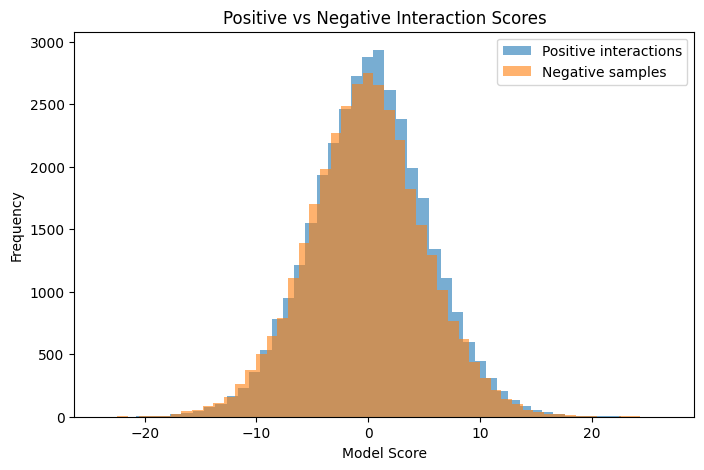

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    positive_scores.detach().numpy(),
    bins=50,
    alpha=0.6,
    label="Positive interactions"
)

plt.hist(
    negative_scores.detach().numpy(),
    bins=50,
    alpha=0.6,
    label="Negative samples"
)

plt.xlabel("Model Score")
plt.ylabel("Frequency")
plt.title("Positive vs Negative Interaction Scores")
plt.legend()
plt.show()

### Mini-Batch Training

The previous training used the entire training dataset as one batch for each epoch. We now switch to mini-batch training.

The 70,286 training examples are divided into smaller batches. The model processes one batch at a time, calculates the loss, and updates the user and item embeddings after each batch.

Mini-batch training provides more frequent parameter updates and is a standard approach for training recommendation models.

The validation data remains separate and is still used only for evaluation.

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Combine the training tensors into a dataset
train_dataset = TensorDataset(
    train_user_tensor,
    train_movie_tensor,
    train_label_tensor
)

# Split the training data into mini-batches
train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True
)

print("Training examples:", len(train_dataset))
print("Number of batches:", len(train_loader))

Training examples: 70286
Number of batches: 138


### Creating a Fresh Baseline Model

The previous model was trained using full-batch training. Since we are changing the training procedure to mini-batch training, we create a fresh Matrix Factorization model.

This ensures that the new training starts with newly initialized embeddings rather than continuing from the previously trained model.

The model architecture remains unchanged: 32-dimensional user embeddings and 32-dimensional movie embeddings.

In [ ]:
# Create a fresh Matrix Factorization model
model = MatrixFactorization(
    num_users,
    num_items,
    embedding_dim=32
)

# Create a new loss function and optimizer
loss_function = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

MatrixFactorization(
  (user_embedding): Embedding(942, 32)
  (item_embedding): Embedding(1413, 32)
)


### Mini-Batch Training with Validation

We now train the fresh Matrix Factorization model using mini-batches.

For each batch, the model:
1. Retrieves the user and movie embeddings.
2. Calculates interaction scores.
3. Calculates the BCE loss.
4. Computes gradients using backpropagation.
5. Updates the embeddings using Adam.

After processing all training batches in an epoch, we evaluate the model on the complete validation set.

We use early stopping to stop training if the validation loss stops improving. The model with the lowest validation loss is saved and restored at the end.

This trained model will be used as our Cycle 0 baseline.

In [ ]:
epochs = 50
patience = 5

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

for epoch in range(epochs):

    model.train()
    total_train_loss = 0

    for batch_users, batch_movies, batch_labels in train_loader:

        optimizer.zero_grad()

        scores = model(batch_users, batch_movies)

        loss = loss_function(scores, batch_labels)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item() * len(batch_labels)

    average_train_loss = total_train_loss / len(train_dataset)

    model.eval()

    with torch.no_grad():
        val_scores = model(val_user_tensor, val_movie_tensor)
        val_loss = loss_function(
            val_scores,
            val_label_tensor
        )

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()

        best_model_state = {
            key: value.clone()
            for key, value in model.state_dict().items()
        }

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Train Loss: {average_train_loss:.4f} | "
        f"Val Loss: {val_loss.item():.4f}"
    )

    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_model_state)

print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch 01 | Train Loss: 2.3292 | Val Loss: 2.2849
Epoch 02 | Train Loss: 2.2282 | Val Loss: 2.2394
Epoch 03 | Train Loss: 2.1329 | Val Loss: 2.1957
Epoch 04 | Train Loss: 2.0420 | Val Loss: 2.1538
Epoch 05 | Train Loss: 1.9551 | Val Loss: 2.1137
Epoch 06 | Train Loss: 1.8724 | Val Loss: 2.0751
Epoch 07 | Train Loss: 1.7935 | Val Loss: 2.0382
Epoch 08 | Train Loss: 1.7185 | Val Loss: 2.0027
Epoch 09 | Train Loss: 1.6469 | Val Loss: 1.9687
Epoch 10 | Train Loss: 1.5786 | Val Loss: 1.9362
Epoch 11 | Train Loss: 1.5136 | Val Loss: 1.9047
Epoch 12 | Train Loss: 1.4517 | Val Loss: 1.8743
Epoch 13 | Train Loss: 1.3928 | Val Loss: 1.8455
Epoch 14 | Train Loss: 1.3366 | Val Loss: 1.8174
Epoch 15 | Train Loss: 1.2829 | Val Loss: 1.7905
Epoch 16 | Train Loss: 1.2318 | Val Loss: 1.7646
Epoch 17 | Train Loss: 1.1830 | Val Loss: 1.7397
Epoch 18 | Train Loss: 1.1365 | Val Loss: 1.7156
Epoch 19 | Train Loss: 1.0921 | Val Loss: 1.6922
Epoch 20 | Train Loss: 1.0497 | Val Loss: 1.6699
Epoch 21 | Train Los

### Sanity Check After Mini-Batch Training

We now repeat the positive-versus-negative score check using the newly trained mini-batch model.

The model should assign higher scores to positive interactions than to the sampled negative interactions.

This allows us to verify that the new training procedure has learned meaningful preference patterns before evaluating its Top-K recommendations.

In [ ]:
# Put the newly trained model into evaluation mode
model.eval()

with torch.no_grad():
    train_scores = model(
        train_user_tensor,
        train_movie_tensor
    )

# Separate positive and negative training scores
positive_scores = train_scores[train_label_tensor == 1]
negative_scores = train_scores[train_label_tensor == 0]

print("Average positive score:", positive_scores.mean().item())
print("Average negative score:", negative_scores.mean().item())

Average positive score: 2.0815436840057373
Average negative score: -2.163672685623169


### Generating Recommendations with the Improved Baseline

The Matrix Factorization model has now been retrained using mini-batch training.

We generate a new Top-10 recommendation list for every user using this improved model. Previously seen movies are excluded, just as before.

These recommendations will be evaluated against the untouched test set to obtain the updated Cycle 0 baseline metrics.

In [ ]:
# Generate Top-10 recommendations using the newly trained model
K = 10

model.eval()

top_k_recommendations = {}

with torch.no_grad():
    for user_idx in range(num_users):

        # Create the user's index for every movie
        user_tensor_all = torch.full(
            (num_items,),
            user_idx,
            dtype=torch.long
        )

        # Create indices for all movies
        movie_tensor_all = torch.arange(
            num_items,
            dtype=torch.long
        )

        # Score every movie for this user
        scores = model(user_tensor_all, movie_tensor_all)

        # Exclude movies already seen during training
        scores[list(seen_items[user_idx])] = float("-inf")

        # Select the 10 highest-scoring unseen movies
        top_movies = torch.topk(scores, K).indices.tolist()

        top_k_recommendations[user_idx] = top_movies

print("Users evaluated:", len(top_k_recommendations))
print("Example recommendations for user 0:")
print(top_k_recommendations[0])

Users evaluated: 942
Example recommendations for user 0:
[436, 187, 672, 303, 356, 639, 460, 1018, 583, 1193]


### Evaluating the Improved Baseline

We now evaluate the Top-10 recommendations produced by the mini-batch-trained model.

For each user, we compare the recommended movies with the user's relevant movies in the test set.

We calculate Precision@10, Recall@10, and NDCG@10 and average the results across all users.

These values will become our final Cycle 0 baseline if the evaluation is correct.

In [ ]:
import numpy as np

K = 10

precisions = []
recalls = []
ndcgs = []

for user_idx, recommendations in top_k_recommendations.items():

    relevant_items = test_positive_items.get(user_idx, set())

    # Find relevant recommendations
    hits = [
        movie for movie in recommendations
        if movie in relevant_items
    ]

    # Precision@10
    precision = len(hits) / K

    # Recall@10
    recall = (
        len(hits) / len(relevant_items)
        if relevant_items else 0
    )

    # Calculate DCG
    dcg = 0.0

    for rank, movie in enumerate(recommendations, start=1):
        if movie in relevant_items:
            dcg += 1 / np.log2(rank + 1)

    # Calculate ideal DCG
    ideal_hits = min(len(relevant_items), K)

    idcg = sum(
        1 / np.log2(rank + 1)
        for rank in range(1, ideal_hits + 1)
    )

    # NDCG
    ndcg = dcg / idcg if idcg > 0 else 0

    precisions.append(precision)
    recalls.append(recall)
    ndcgs.append(ndcg)

print(f"Precision@10: {np.mean(precisions):.4f}")
print(f"Recall@10:    {np.mean(recalls):.4f}")
print(f"NDCG@10:      {np.mean(ndcgs):.4f}")

Precision@10: 0.0138
Recall@10:    0.0077
NDCG@10:      0.0144


### Cycle 0 Popularity Baseline

Before introducing simulated feedback, we record the initial popularity of every movie.

Movie popularity is measured as the number of positive interactions associated with each movie in the training data.

We save this distribution as the Cycle 0 baseline. The visualizations below show how interactions are distributed across movies and help us identify the head, middle, and long-tail portions of the popularity distribution.

These same measurements will be generated again after each feedback cycle so that changes in popularity can be compared over time.

In [ ]:
# Count positive interactions for every movie
cycle0_popularity = (
    train_data["movie_idx"]
    .value_counts()
    .reindex(range(num_items), fill_value=0)
    .sort_index()
)

print("Number of movies:", len(cycle0_popularity))
print("Total positive interactions:", cycle0_popularity.sum())
print("Most popular movie:", cycle0_popularity.max())
print("Least popular movie:", cycle0_popularity.min())

Number of movies: 1413
Total positive interactions: 43929
Most popular movie: 390
Least popular movie: 1


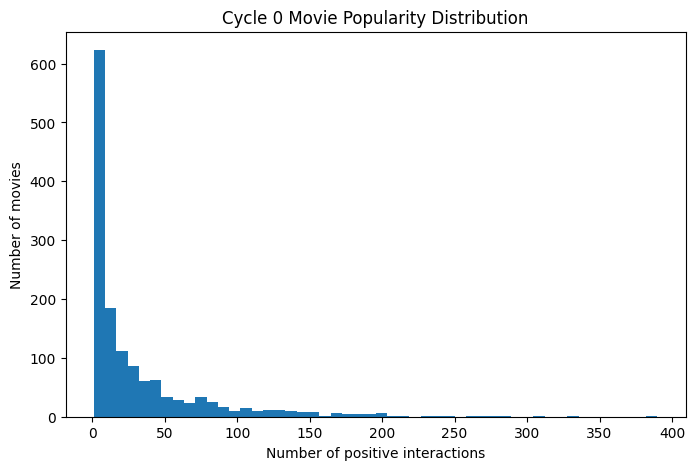

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    cycle0_popularity,
    bins=50
)

plt.xlabel("Number of positive interactions")
plt.ylabel("Number of movies")
plt.title("Cycle 0 Movie Popularity Distribution")

plt.show()

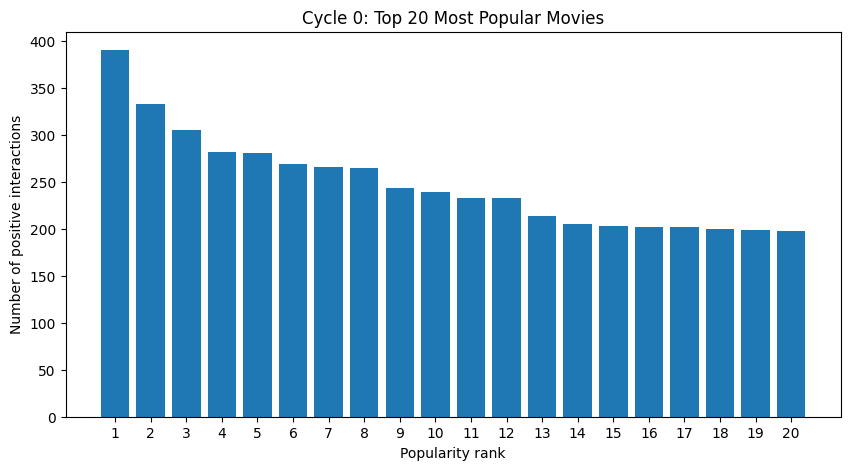

In [ ]:
top20_popular = cycle0_popularity.nlargest(20)

plt.figure(figsize=(10, 5))

plt.bar(
    range(1, 21),
    top20_popular.values
)

plt.xlabel("Popularity rank")
plt.ylabel("Number of positive interactions")
plt.title("Cycle 0: Top 20 Most Popular Movies")

plt.xticks(range(1, 21))

plt.show()

In [ ]:
# Calculate the popularity thresholds
p20 = cycle0_popularity.quantile(0.20)
p80 = cycle0_popularity.quantile(0.80)

# Assign each movie to a popularity group
cycle0_groups = pd.cut(
    cycle0_popularity,
    bins=[-1, p20, p80, float("inf")],
    labels=["Long-tail", "Middle", "Head"]
)

group_counts = cycle0_groups.value_counts()

print(group_counts)

count
Middle       817
Long-tail    314
Head         282
Name: count, dtype: int64


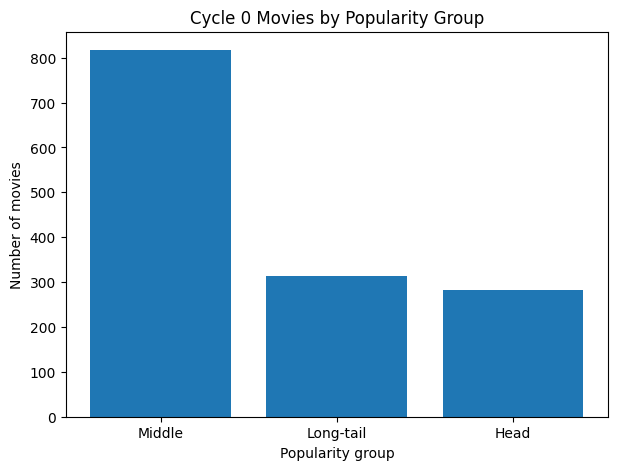

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    group_counts.index,
    group_counts.values
)

plt.xlabel("Popularity group")
plt.ylabel("Number of movies")
plt.title("Cycle 0 Movies by Popularity Group")

plt.show()

### Cycle 0 Popularity Statistics

The Cycle 0 popularity distribution is now summarized using numerical statistics.

We record the total number of positive interactions, the average and median movie popularity, the maximum popularity, and the popularity of the Head, Middle, and Long-tail groups.

These values provide a numerical reference for measuring how the popularity distribution changes after simulated feedback is introduced.

In [ ]:
# Calculate Cycle 0 popularity statistics
cycle0_stats = {
    "Total positive interactions": int(cycle0_popularity.sum()),
    "Average interactions per movie": cycle0_popularity.mean(),
    "Median interactions per movie": cycle0_popularity.median(),
    "Maximum interactions": cycle0_popularity.max(),
    "20th percentile": cycle0_popularity.quantile(0.20),
    "80th percentile": cycle0_popularity.quantile(0.80)
}

for name, value in cycle0_stats.items():
    print(f"{name}: {value:.2f}" if isinstance(value, float) else f"{name}: {value}")

Total positive interactions: 43929
Average interactions per movie: 31.09
Median interactions per movie: 11.00
Maximum interactions: 390
20th percentile: 2.00
80th percentile: 48.00


In [ ]:
# Calculate interaction share for each popularity group
group_interaction_counts = (
    cycle0_popularity
    .groupby(cycle0_groups)
    .sum()
)

group_interaction_proportion = (
    group_interaction_counts /
    group_interaction_counts.sum() * 100
)

print("Cycle 0 interaction share:")
print(group_interaction_proportion)

Cycle 0 interaction share:
count
Long-tail     1.012998
Middle       30.562954
Head         68.424048
Name: count, dtype: float64


/tmp/ipykernel_2718/384589462.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cycle0_groups)


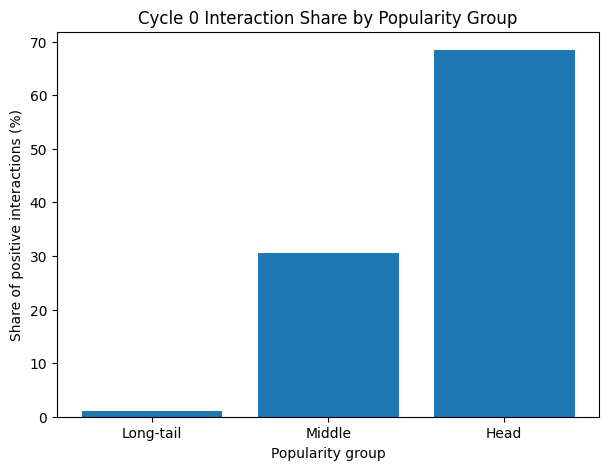

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    group_interaction_proportion.index,
    group_interaction_proportion.values
)

plt.xlabel("Popularity group")
plt.ylabel("Share of positive interactions (%)")
plt.title("Cycle 0 Interaction Share by Popularity Group")

plt.show()

In [ ]:
print("Cycle 0 interaction share (%)")
print(group_interaction_proportion.round(2))

Cycle 0 interaction share (%)
count
Long-tail     1.01
Middle       30.56
Head         68.42
Name: count, dtype: float64


### Saving the Cycle 0 Embeddings

The trained Matrix Factorization model represents each user and movie using learned 32-dimensional embeddings.

Before introducing simulated feedback, we save the current embeddings as the Cycle 0 baseline.

These embeddings will later be compared with the embeddings learned after each feedback cycle to measure how the representation of users and movies changes over time.

In [ ]:
# Save a fixed copy of the Cycle 0 embeddings
cycle0_user_embeddings = model.user_embedding.weight.detach().cpu().clone()
cycle0_item_embeddings = model.item_embedding.weight.detach().cpu().clone()

print("Cycle 0 user embeddings:", cycle0_user_embeddings.shape)
print("Cycle 0 item embeddings:", cycle0_item_embeddings.shape)

Cycle 0 user embeddings: torch.Size([942, 32])
Cycle 0 item embeddings: torch.Size([1413, 32])


In [ ]:
# Save the embeddings to the Colab filesystem
torch.save(cycle0_user_embeddings, "cycle0_user_embeddings.pt")
torch.save(cycle0_item_embeddings, "cycle0_item_embeddings.pt")

print("Cycle 0 embeddings saved successfully.")

Cycle 0 embeddings saved successfully.


In [ ]:
import os

print(os.path.exists("cycle0_user_embeddings.pt"))
print(os.path.exists("cycle0_item_embeddings.pt"))

True
True


### Cycle 0 Movie Embedding Visualization

Each movie is represented by a 32-dimensional embedding learned by the Matrix Factorization model.

Since 32 dimensions cannot be directly visualized, PCA (Principal Component Analysis) is used to reduce the embeddings to two dimensions.

Each point in the plot represents one movie. Movies that are closer together in this reduced space have more similar learned representations.

Movies are colored according to their Cycle 0 popularity group: Head, Middle, or Long-tail.

This visualization provides a reference for comparing how the movie embedding space changes after subsequent feedback cycles.

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Convert the saved PyTorch embeddings to NumPy
embedding_matrix = cycle0_item_embeddings.numpy()

# Reduce 32 dimensions to 2 dimensions
pca = PCA(n_components=2)
embedding_2d = pca.fit_transform(embedding_matrix)

print("Original embedding shape:", embedding_matrix.shape)
print("Reduced embedding shape:", embedding_2d.shape)
print("Explained variance:", pca.explained_variance_ratio_)

Original embedding shape: (1413, 32)
Reduced embedding shape: (1413, 2)
Explained variance: [0.05103859 0.04112818]


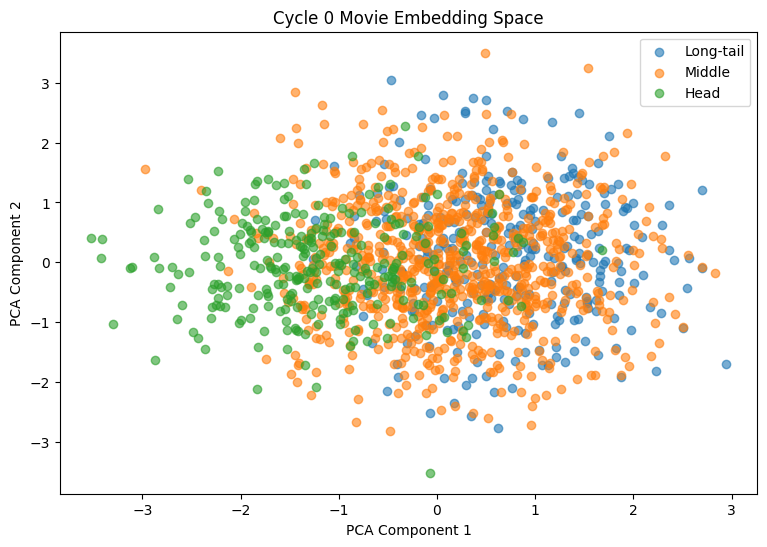

In [ ]:
plt.figure(figsize=(9, 6))

for group in ["Long-tail", "Middle", "Head"]:

    mask = cycle0_groups == group

    plt.scatter(
        embedding_2d[mask, 0],
        embedding_2d[mask, 1],
        label=group,
        alpha=0.6
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Cycle 0 Movie Embedding Space")
plt.legend()
plt.show()

In [ ]:
plt.savefig("cycle0_movie_embeddings.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Simulating User Feedback

The Cycle 0 recommendation model has generated a Top-10 recommendation list for each user.

We now simulate positive user feedback on a subset of these recommendations. A fixed feedback probability is used for every recommendation so that popularity does not directly determine whether an item receives feedback.

The resulting feedback interactions will later be added to the training data and used to retrain the recommendation model.

Repeating this recommendation and feedback process across multiple cycles allows us to study whether the existing popularity imbalance becomes amplified over time.

In [ ]:
import numpy as np

# Probability that a recommended movie receives positive feedback
feedback_probability = 0.20

# Make the random simulation reproducible
np.random.seed(42)

print("Feedback probability:", feedback_probability)

Feedback probability: 0.2


In [ ]:
# Total number of recommendation events
num_recommendations = num_users * K

# Generate a random value for every recommendation
random_values = np.random.random(num_recommendations)

# Mark recommendations that receive positive feedback
feedback_mask = random_values < feedback_probability

print("Total recommendations:", num_recommendations)
print("Simulated positive feedback:", feedback_mask.sum())
print("Feedback rate:", feedback_mask.mean() * 100, "%")

Total recommendations: 9420
Simulated positive feedback: 1923
Feedback rate: 20.414012738853504 %


### Analyzing Simulated Feedback by Popularity Group

Before adding the simulated feedback to the training data, we examine which popularity groups received the new interactions.

Each recommended movie had the same probability of receiving positive feedback, regardless of its popularity.

We compare the feedback received by Head, Middle, and Long-tail movies to understand how the existing recommendation distribution influences the feedback that is generated.

This provides an important intermediate measurement before the feedback is incorporated into the next training cycle.

In [ ]:
# Convert the Top-K recommendations into a flat list
feedback_records = []

for user_idx, recommendations in top_k_recommendations.items():

    for rank, movie_idx in enumerate(recommendations):

        if feedback_mask[user_idx * K + rank]:

            feedback_records.append({
                "user_idx": user_idx,
                "movie_idx": movie_idx,
                "rank": rank + 1
            })

feedback_data = pd.DataFrame(feedback_records)

print("Feedback interactions:", len(feedback_data))
print(feedback_data.head())

Feedback interactions: 1923
   user_idx  movie_idx  rank
0         0        356     5
1         0        639     6
2         0        460     7
3         1       1063     1
4         1       1238     5


In [ ]:
# Assign each feedback movie to its Cycle 0 popularity group
feedback_data["popularity_group"] = (
    feedback_data["movie_idx"]
    .map(cycle0_groups)
)

print(feedback_data["popularity_group"].value_counts())

popularity_group
Middle       1168
Long-tail     434
Head          321
Name: count, dtype: int64


In [ ]:
feedback_group_counts = (
    feedback_data["popularity_group"]
    .value_counts()
)

feedback_group_proportion = (
    feedback_group_counts /
    feedback_group_counts.sum() * 100
)

print("Feedback share by popularity group:")
print(feedback_group_proportion.round(2))

Feedback share by popularity group:
popularity_group
Middle       60.74
Long-tail    22.57
Head         16.69
Name: count, dtype: float64


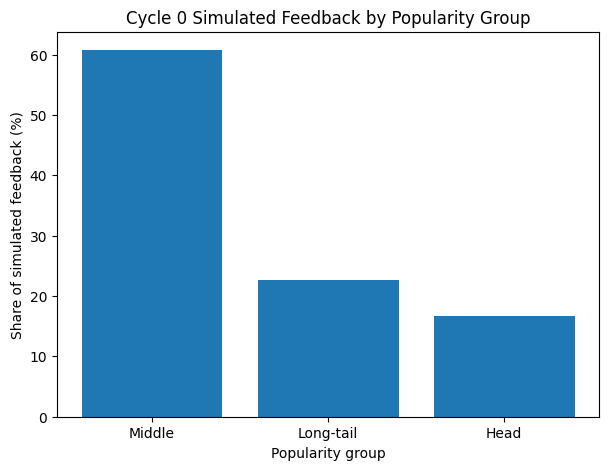

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    feedback_group_proportion.index,
    feedback_group_proportion.values
)

plt.xlabel("Popularity group")
plt.ylabel("Share of simulated feedback (%)")
plt.title("Cycle 0 Simulated Feedback by Popularity Group")

plt.show()

### Feedback Exposure by Popularity Group

The previous analysis showed the overall share of simulated feedback received by each popularity group.

However, the popularity groups contain different numbers of movies. Therefore, comparing their total feedback alone can be misleading.

We now calculate the average number of simulated feedback interactions received per movie within each group.

This helps us determine whether movies in a particular popularity group receive disproportionately more feedback relative to the number of movies in that group.

In [ ]:
# Number of movies in each popularity group
movies_per_group = cycle0_groups.value_counts()

# Total simulated feedback received by each group
feedback_per_group = feedback_data["popularity_group"].value_counts()

# Make sure all groups are included
feedback_per_group = feedback_per_group.reindex(
    movies_per_group.index,
    fill_value=0
)

# Average feedback received per movie
feedback_per_movie = (
    feedback_per_group / movies_per_group
)

print("Movies per group:")
print(movies_per_group)

print("\nFeedback interactions per group:")
print(feedback_per_group)

print("\nAverage feedback per movie:")
print(feedback_per_movie.round(2))

Movies per group:
count
Middle       817
Long-tail    314
Head         282
Name: count, dtype: int64

Feedback interactions per group:
count
Middle       1168
Long-tail     434
Head          321
Name: count, dtype: int64

Average feedback per movie:
count
Middle       1.43
Long-tail    1.38
Head         1.14
Name: count, dtype: float64


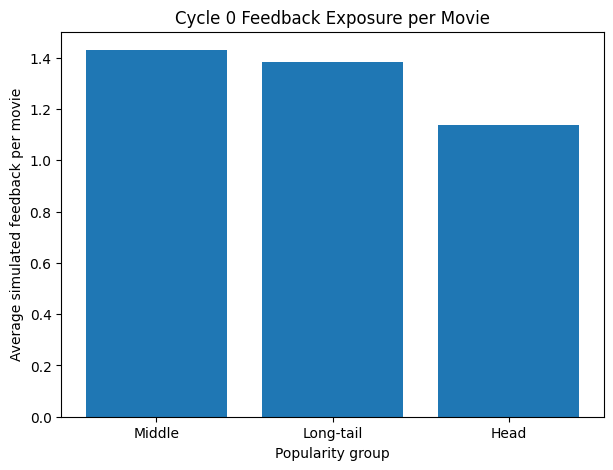

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    feedback_per_movie.index,
    feedback_per_movie.values
)

plt.xlabel("Popularity group")
plt.ylabel("Average simulated feedback per movie")
plt.title("Cycle 0 Feedback Exposure per Movie")

plt.show()

### Adding Simulated Feedback to the Training Data

The simulated positive feedback has been analyzed and recorded as part of the Cycle 0 baseline.

We now add these feedback interactions to the original training interactions. These new interactions represent the behavior generated by the recommendation-feedback loop.

The expanded dataset will be used to retrain the Matrix Factorization model, producing the next recommendation cycle.

The original interactions are preserved, while the simulated feedback is appended as additional positive interactions.

In [ ]:
# Keep only the columns needed for training
feedback_training_data = feedback_data[
    ["user_idx", "movie_idx"]
].copy()

# Add the positive-interaction label
feedback_training_data["label"] = 1

# Combine original training data with simulated feedback
cycle1_training_data = pd.concat(
    [
        mf_training_data[["user_idx", "movie_idx", "label"]],
        feedback_training_data
    ],
    ignore_index=True
)

print("Original training examples:", len(mf_training_data))
print("New feedback interactions:", len(feedback_training_data))
print("Cycle 1 training examples:", len(cycle1_training_data))

print("\nLabel distribution:")
print(cycle1_training_data["label"].value_counts())

Original training examples: 70286
New feedback interactions: 1923
Cycle 1 training examples: 72209

Label distribution:
label
1    37066
0    35143
Name: count, dtype: int64


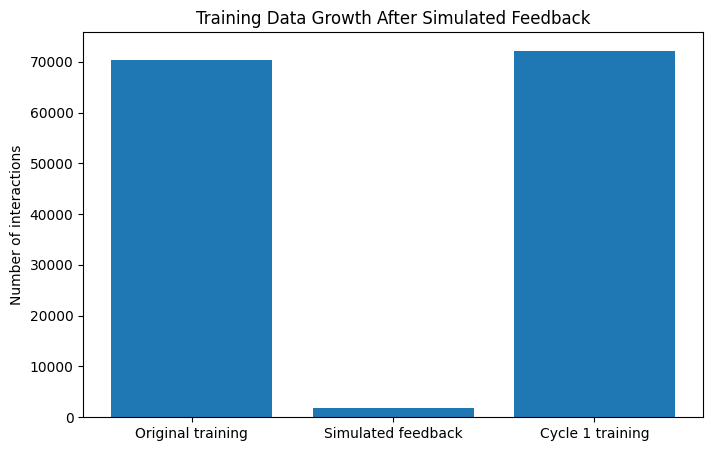

In [ ]:
training_counts = [
    len(mf_training_data),
    len(feedback_training_data),
    len(cycle1_training_data)
]

labels = [
    "Original training",
    "Simulated feedback",
    "Cycle 1 training"
]

plt.figure(figsize=(8, 5))

plt.bar(labels, training_counts)

plt.ylabel("Number of interactions")
plt.title("Training Data Growth After Simulated Feedback")

plt.show()

### Retraining the Matrix Factorization Model

The Cycle 1 training dataset now contains the original interactions together with the simulated positive feedback generated from Cycle 0 recommendations.

A new Matrix Factorization model is trained using this expanded dataset.

The Cycle 0 model is kept unchanged so that it can continue to serve as the baseline. The newly trained model represents the recommendation system after one round of simulated feedback.

After training, we will generate new recommendations and compare the model's performance, popularity distribution, and embedding space with Cycle 0.

In [ ]:
import torch

cycle1_user_tensor = torch.tensor(
    cycle1_training_data["user_idx"].values,
    dtype=torch.long
)

cycle1_movie_tensor = torch.tensor(
    cycle1_training_data["movie_idx"].values,
    dtype=torch.long
)

cycle1_label_tensor = torch.tensor(
    cycle1_training_data["label"].values,
    dtype=torch.float32
)

print("Cycle 1 user tensor:", cycle1_user_tensor.shape)
print("Cycle 1 movie tensor:", cycle1_movie_tensor.shape)
print("Cycle 1 label tensor:", cycle1_label_tensor.shape)

Cycle 1 user tensor: torch.Size([72209])
Cycle 1 movie tensor: torch.Size([72209])
Cycle 1 label tensor: torch.Size([72209])


### Preparing Cycle 1 Validation Data

The validation data remains unchanged from Cycle 0.

We keep the same validation interactions so that the performance of the Cycle 0 and Cycle 1 models can be compared fairly.

Only the training data changes between cycles; the validation data is kept fixed.

In [ ]:
# Use the same validation data as Cycle 0
cycle1_val_user_tensor = torch.tensor(
    mf_validation_data["user_idx"].values,
    dtype=torch.long
)

cycle1_val_movie_tensor = torch.tensor(
    mf_validation_data["movie_idx"].values,
    dtype=torch.long
)

cycle1_val_label_tensor = torch.tensor(
    mf_validation_data["label"].values,
    dtype=torch.float32
)

print("Cycle 1 validation user tensor:", cycle1_val_user_tensor.shape)
print("Cycle 1 validation movie tensor:", cycle1_val_movie_tensor.shape)
print("Cycle 1 validation label tensor:", cycle1_val_label_tensor.shape)

Cycle 1 validation user tensor: torch.Size([17572])
Cycle 1 validation movie tensor: torch.Size([17572])
Cycle 1 validation label tensor: torch.Size([17572])


### Creating the Cycle 1 Model

A new Matrix Factorization model is initialized for Cycle 1.

The model has the same architecture as the Cycle 0 model: 32-dimensional user and movie embeddings.

The new model starts with fresh embedding values and will learn from the expanded Cycle 1 training data, which includes the simulated feedback.

Keeping the architecture unchanged ensures that differences between Cycle 0 and Cycle 1 are caused by the additional feedback data rather than by changing the model structure.

In [ ]:
# Create a fresh Cycle 1 Matrix Factorization model
cycle1_model = MatrixFactorization(
    num_users=num_users,
    num_items=num_items,
    embedding_dim=32
)

print(cycle1_model)

MatrixFactorization(
  (user_embedding): Embedding(942, 32)
  (item_embedding): Embedding(1413, 32)
)


### Training the Cycle 1 Model

The new Matrix Factorization model is now trained using the Cycle 1 training data.

The training data contains the original interactions plus the simulated positive feedback generated from the Cycle 0 recommendations.

The validation set remains unchanged, allowing us to compare Cycle 1 with the Cycle 0 baseline under the same validation conditions.

After training, the resulting embeddings and recommendation scores will represent the recommendation system after one feedback cycle.

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Create the Cycle 1 training dataset
cycle1_dataset = TensorDataset(
    cycle1_user_tensor,
    cycle1_movie_tensor,
    cycle1_label_tensor
)

# Mini-batches
cycle1_loader = DataLoader(
    cycle1_dataset,
    batch_size=256,
    shuffle=True
)

# Validation dataset
cycle1_val_dataset = TensorDataset(
    cycle1_val_user_tensor,
    cycle1_val_movie_tensor,
    cycle1_val_label_tensor
)

cycle1_val_loader = DataLoader(
    cycle1_val_dataset,
    batch_size=256,
    shuffle=False
)

In [ ]:
import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    cycle1_model.parameters(),
    lr=0.01
)

epochs = 50
patience = 5

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

cycle1_train_losses = []
cycle1_val_losses = []

for epoch in range(epochs):

    # Training
    cycle1_model.train()
    train_loss = 0

    for users, movies, labels in cycle1_loader:

        optimizer.zero_grad()

        scores = cycle1_model(users, movies)

        loss = criterion(scores, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(labels)

    train_loss /= len(cycle1_dataset)

    # Validation
    cycle1_model.eval()
    val_loss = 0

    with torch.no_grad():

        for users, movies, labels in cycle1_val_loader:

            scores = cycle1_model(users, movies)

            loss = criterion(scores, labels)

            val_loss += loss.item() * len(labels)

    val_loss /= len(cycle1_val_dataset)

    cycle1_train_losses.append(train_loss)
    cycle1_val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {
            key: value.clone()
            for key, value in cycle1_model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

# Restore the best model found during training
cycle1_model.load_state_dict(best_model_state)

print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch 01 | Train Loss: 2.0927 | Val Loss: 1.7811
Epoch 02 | Train Loss: 1.1921 | Val Loss: 1.4735
Epoch 03 | Train Loss: 0.7529 | Val Loss: 1.2830
Epoch 04 | Train Loss: 0.5134 | Val Loss: 1.1543
Epoch 05 | Train Loss: 0.3752 | Val Loss: 1.0837
Epoch 06 | Train Loss: 0.2927 | Val Loss: 1.0599
Epoch 07 | Train Loss: 0.2394 | Val Loss: 1.0650
Epoch 08 | Train Loss: 0.1996 | Val Loss: 1.0893
Epoch 09 | Train Loss: 0.1684 | Val Loss: 1.1250
Epoch 10 | Train Loss: 0.1410 | Val Loss: 1.1725
Epoch 11 | Train Loss: 0.1177 | Val Loss: 1.2231
Epoch 12 | Train Loss: 0.0976 | Val Loss: 1.2861
Epoch 13 | Train Loss: 0.0815 | Val Loss: 1.3485
Epoch 14 | Train Loss: 0.0651 | Val Loss: 1.4160
Epoch 15 | Train Loss: 0.0524 | Val Loss: 1.4854
Epoch 16 | Train Loss: 0.0416 | Val Loss: 1.5529
Epoch 17 | Train Loss: 0.0329 | Val Loss: 1.6248
Epoch 18 | Train Loss: 0.0257 | Val Loss: 1.6932
Epoch 19 | Train Loss: 0.0200 | Val Loss: 1.7592
Epoch 20 | Train Loss: 0.0155 | Val Loss: 1.8253
Epoch 21 | Train Los

### Cycle 1 Training and Validation Loss

The training and validation losses are plotted across epochs to examine how the Cycle 1 model learns from the expanded training data.

The training loss continues to decrease throughout training, while the validation loss reaches its minimum around epoch 6 and then begins to increase.

This indicates that the model starts overfitting after the validation loss reaches its minimum. Therefore, the model from the epoch with the lowest validation loss should be used rather than the final epoch.

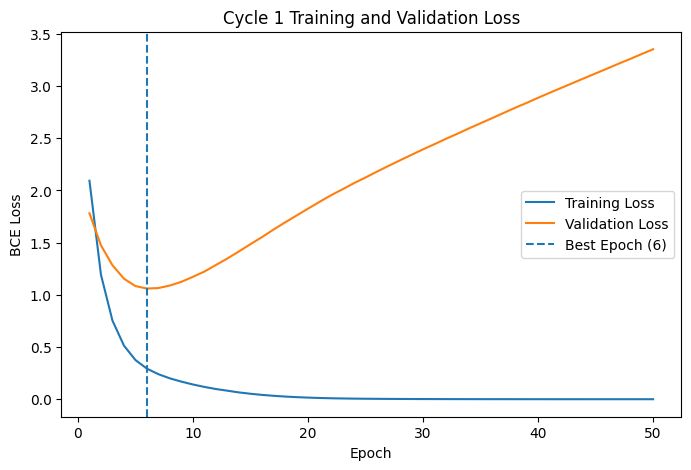

Best epoch: 6
Best validation loss: 1.0598959568618


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cycle1_train_losses) + 1),
    cycle1_train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, len(cycle1_val_losses) + 1),
    cycle1_val_losses,
    label="Validation Loss"
)

best_epoch = np.argmin(cycle1_val_losses) + 1
best_val_loss = min(cycle1_val_losses)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Cycle 1 Training and Validation Loss")
plt.legend()
plt.show()

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)